## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [2]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
# TODO: check the dataset size with df.shape
df.shape[0], df.shape[1]

(3900, 19)

In [5]:
# TODO: drop the Customer ID column  
df = df.drop(columns=['Customer ID'])

### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [6]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   str    
 2   Item Purchased            3900 non-null   str    
 3   Category                  3900 non-null   str    
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   str    
 6   Size                      3900 non-null   str    
 7   Color                     3900 non-null   str    
 8   Season                    3900 non-null   str    
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   str    
 11  Payment Method            3900 non-null   str    
 12  Shipping Type             3900 non-null   str    
 13  Discount Applied          3900 non-null   str    
 14  Promo Code Used    

In [7]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [8]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [9]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [10]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
# male_df = ?
# female_df = ?
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']

print('Male data:')
display(male_df.head())
print('Female data:')
display(female_df.head())

Male data:


,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


Female data:


,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
2652,23,Female,Shorts,Clothing,20,Maryland,L,Cyan,Summer,3.3,No,Debit Card,2-Day Shipping,No,No,46,Credit Card,Monthly
2653,67,Female,Blouse,Clothing,36,Wisconsin,L,Lavender,Fall,4.8,No,Credit Card,Express,No,No,24,Venmo,Every 3 Months
2654,23,Female,Coat,Outerwear,70,Idaho,S,Pink,Fall,4.1,No,Debit Card,Next Day Air,No,No,4,PayPal,Annually
2655,26,Female,Sunglasses,Accessories,83,Wyoming,M,Gray,Summer,3.4,No,Credit Card,Standard,No,No,2,Credit Card,Fortnightly
2656,52,Female,Shorts,Clothing,76,Indiana,L,Yellow,Winter,3.6,No,Bank Transfer,Express,No,No,29,Bank Transfer,Fortnightly


## **EDA**

### **Item Purchased**

In [11]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
print("male data:")
display(male_df['Item Purchased'].value_counts().reset_index().head())
print("female data:")
display(female_df['Item Purchased'].value_counts().reset_index().head())

print("all data:")
display(df['Item Purchased'].value_counts().reset_index().head())

male data:


,Item Purchased,count
0,Pants,123
1,Jewelry,119
2,Sweater,114
3,Coat,114
4,Dress,114


female data:


,Item Purchased,count
0,Blouse,66
1,Sandals,59
2,Shirt,59
3,Handbag,58
4,Socks,58


all data:


,Item Purchased,count
0,Blouse,171
1,Pants,171
2,Jewelry,171
3,Shirt,169
4,Dress,166


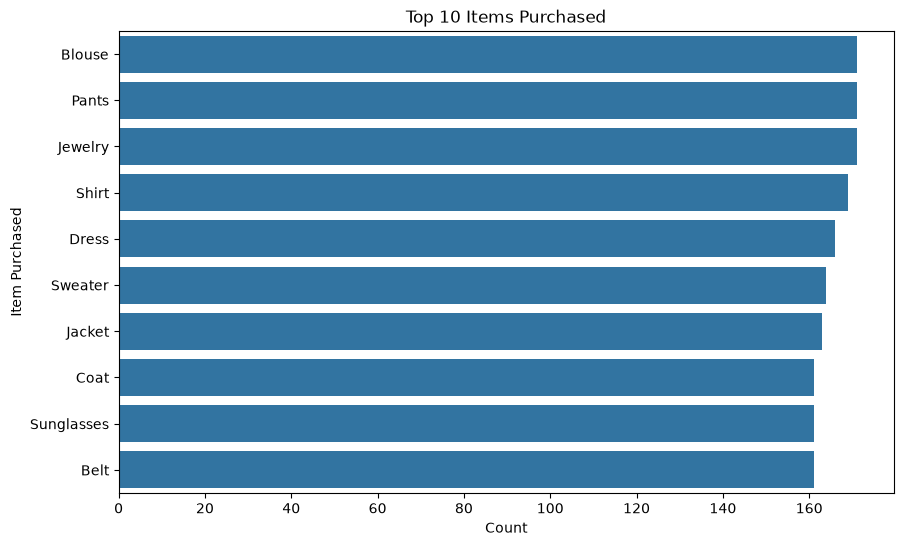

In [12]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
top_10 = (df['Item Purchased'].value_counts().reset_index().head(10))
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10,
    x = 'count',
    y = 'Item Purchased',
    legend=False
)
plt.title('Top 10 Items Purchased')
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     ?
#     legend=?
# )
# plt.title?
# plt.xlabel?
# plt.ylabel?
# plt.show()

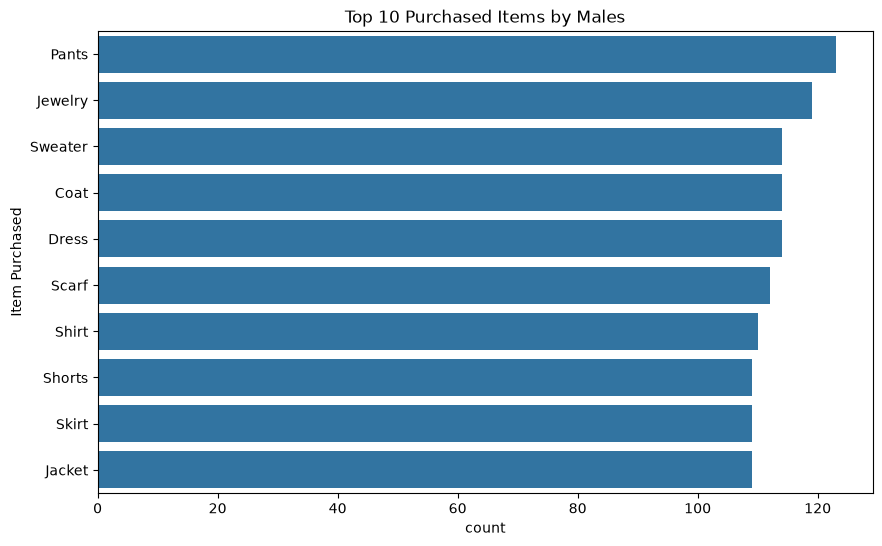

In [13]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
top_10_male = (male_df['Item Purchased'].value_counts().reset_index().head(10))
plt.figure(figsize=(10, 6))
sns.barplot(
    data = top_10_male,
    x = 'count',
    y = 'Item Purchased',
    legend=False
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     ?
# )
# plt.title("Top 10 Purchased Items by Males")
# plt.xlabel('count')
# plt.ylabel('Item Purchased')
# plt.show()

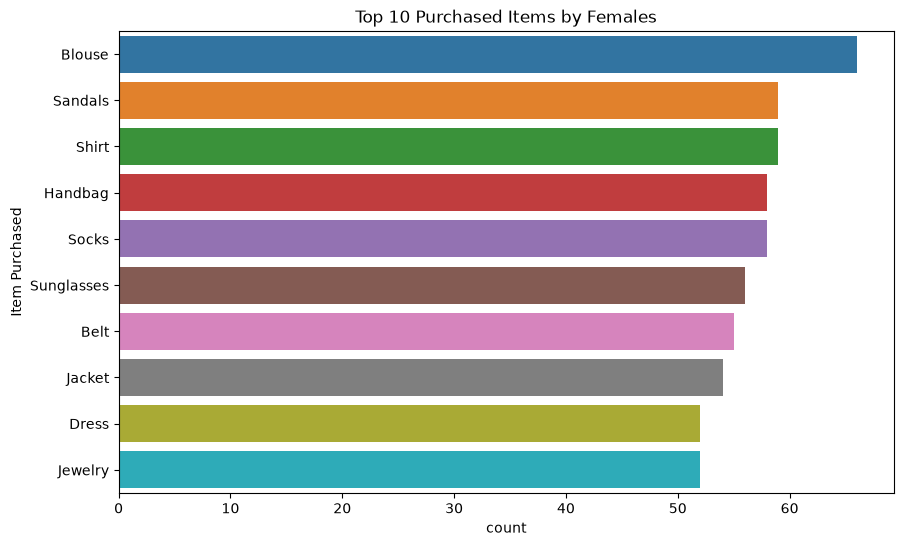

In [14]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
top_10_female = (female_df['Item Purchased'].value_counts().reset_index().head(10))
plt.figure(figsize=(10, 6))
sns.barplot(
    data = top_10_female,
    x = 'count', 
    y = 'Item Purchased',
    hue = 'Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     data=top_item_f.head(10),
#     y='Item Purchased',
#     x='count',
#     hue='Item Purchased',
#     dodge=False,
#     legend=False
# )
# plt.title("Top 10 Purchased Items by Females")
# plt.xlabel('count')
# plt.ylabel('Item Purchased')
# plt.show()

In [15]:
# TODO: count Size with value_counts() for all customers
df['Size'].value_counts()

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

In [16]:
# TODO: count Size with value_counts() for male_df and female_df
print("Male Size Counts:")
print(male_df['Size'].value_counts())
print("Female Size Counts:")
print(female_df['Size'].value_counts())

Male Size Counts:
Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64
Female Size Counts:
Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64


### **Category**

In [17]:
# TODO: count Category with value_counts().reset_index() for all customers
# ctg = ?
ctg = df['Category'].value_counts().reset_index()
ctg.columns = ['Category', 'Count']
print(ctg)

      Category  Count
0     Clothing   1737
1  Accessories   1240
2     Footwear    599
3    Outerwear    324


In [18]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
m_ctg = male_df['Category'].value_counts().reset_index()
m_ctg.columns = ['Category', 'Count']
print("Male Category Counts:")
print(m_ctg)

f_ctg = female_df['Category'].value_counts().reset_index()
f_ctg.columns = ['Category', 'Count']
print("Female Category Counts:")
print(f_ctg)

Male Category Counts:
      Category  Count
0     Clothing   1181
1  Accessories    848
2     Footwear    400
3    Outerwear    223
Female Category Counts:
      Category  Count
0     Clothing    556
1  Accessories    392
2     Footwear    199
3    Outerwear    101


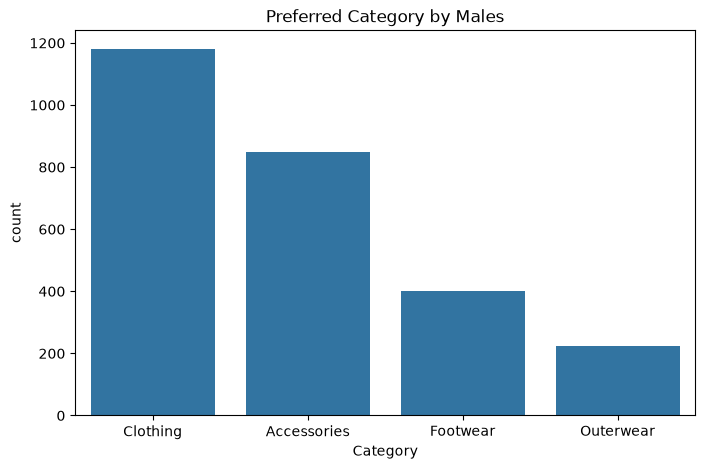

In [19]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
preferred_category_male = male_df['Category'].value_counts().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=preferred_category_male,
    x='Category',
    y='count'
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#     ?
# )
# plt.title("Preferred Category by Males")
# plt.xlabel('Category')
# plt.ylabel('count')
# plt.show()

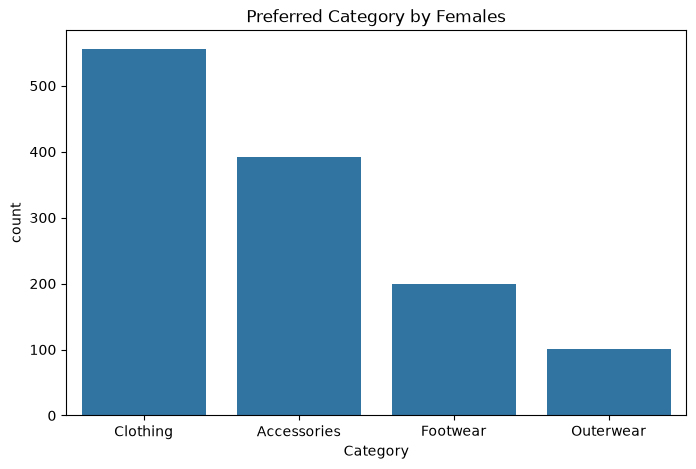

In [20]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
preferred_category_female = female_df['Category'].value_counts().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=preferred_category_female,
    x = 'Category',
    y = 'count',
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#    ?
# )
# plt.title("Preferred Category by Females")
# plt.xlabel('Category')
# plt.ylabel('count')
# plt.show()

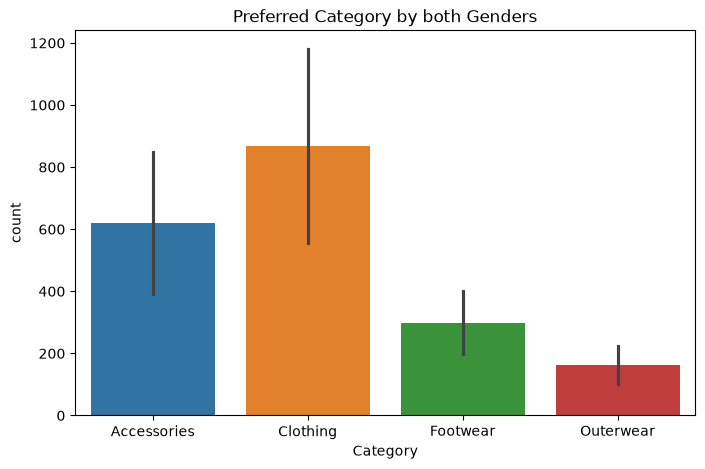

In [21]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
ctg = (df.groupby(['Category', 'Gender']).size().reset_index(name='count'))
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge =False,
    legend=False
)
plt.title("Preferred Category by both Genders")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#     data=ctg,
#     x='Category',
#     y='count',
#     hue='Category',
#     dodge=False,
#     legend=False
# )
# plt.title("Preferred Category by both Genders")
# plt.show()


In [22]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
# waffle_data_m = dict(male_df['Category'].value_counts())
# waffle_data_f = dict(female_df['Category'].value_counts())
waffle_data_m = dict(male_df['Category'].value_counts())

# TODO: create waffle_data_f from female_df['Category'].value_counts()
waffle_data_f = dict(female_df['Category'].value_counts())

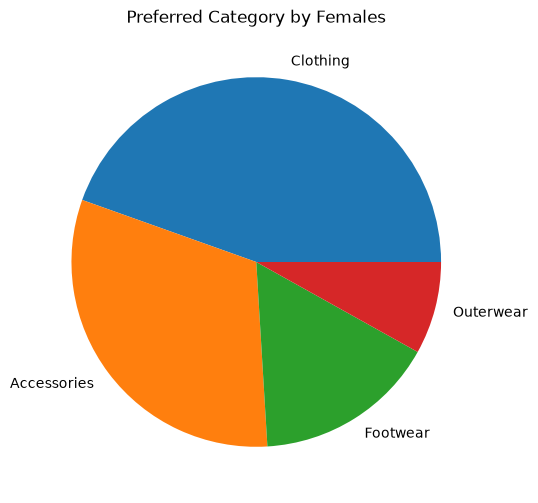

In [27]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
preferred_category_female = female_df['Category'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    preferred_category_female,
    labels=preferred_category_female.index,
)
plt.title("Preferred Category by Females")
plt.show()
# plt.figure(figsize=(6, 6))
# plt.pie(
#    ?
# )
# plt.title("Preferred Category by Females")
# plt.show()

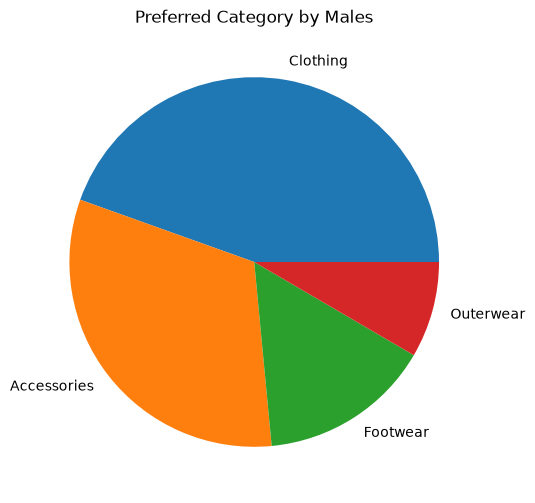

In [26]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
preferred_category_male = male_df['Category'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    preferred_category_male,
    labels=preferred_category_male.index
)
plt.title("Preferred Category by Males")
plt.show()
# plt.figure(figsize=(6, 6))
# plt.pie(
#     waffle_data_m.values(),
#     labels=waffle_data_m.keys(),
#     autopct='%1.1f%%'
# )
# plt.title("Preferred Category by Males")
# plt.show() 

### **Review ratings**

In [51]:
# TODO: filter female Clothing rows, then mean of Review Rating
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()
print(f"Average Review Rating for Female Clothing: {avg_cr_f:.2f}")
# cr_f = ?
# avg_cr_f = ?

Average Review Rating for Female Clothing: 3.70


In [52]:
# TODO: filter male Clothing rows, then mean of Review Rating
# cr_m = ?
# avg_cr_m = ?
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()
print(f"Average Review Rating for Male Clothing: {avg_cr_m:.2f}")

Average Review Rating for Male Clothing: 3.73


In [ ]:
# avg_cr_m,avg_cr_f

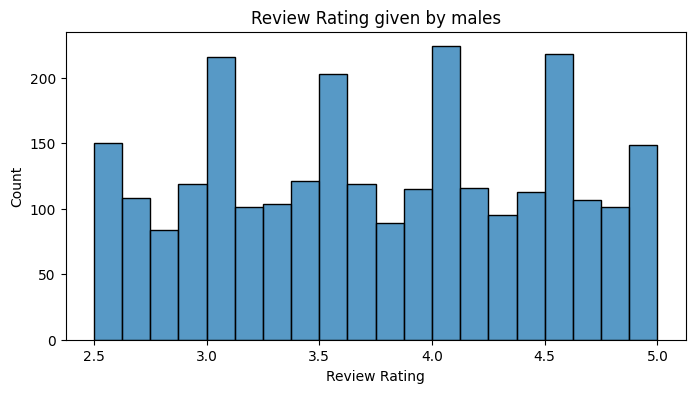

In [73]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
# ?

In [33]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
count_cr_m = cr_m['Review Rating'].value_counts()
print("Review Rating Counts for Male Clothing:")
print(count_cr_m)

Review Rating Counts for Male Clothing:
Review Rating
3.7    61
3.4    59
2.7    55
2.9    55
4.0    52
4.2    52
3.9    52
3.3    49
3.0    49
4.9    48
4.1    48
3.5    48
3.1    46
4.7    46
4.6    46
3.6    46
4.8    46
2.6    45
4.3    45
4.4    43
3.2    41
2.8    41
3.8    39
4.5    36
2.5    17
5.0    16
Name: count, dtype: int64


### **Purchase Amount (USD)**

In [35]:
# TODO: sum Purchase Amount (USD) for males
# m_tpa = ?
m_tpa = male_df['Purchase Amount (USD)'].sum()
print("Total Purchase Amount (USD) for Males:")
print(m_tpa)

# # TODO: sum Purchase Amount (USD) for females
# f_tpa =?
f_tpa = female_df['Purchase Amount (USD)'].sum()
print("Total Purchase Amount (USD) for Females:")
print(f_tpa)

Total Purchase Amount (USD) for Males:
157890
Total Purchase Amount (USD) for Females:
75191


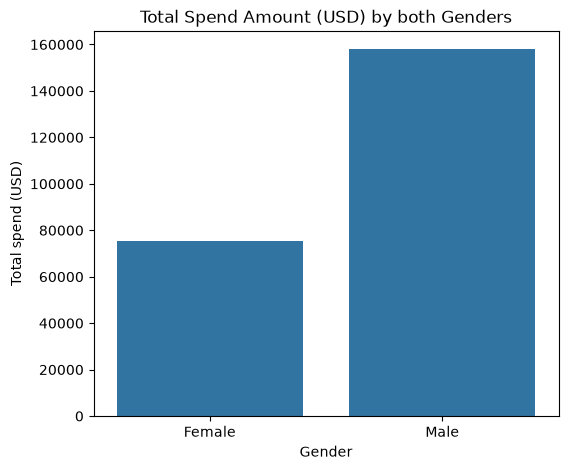

In [36]:
# TODO: plot total spend by gender with sns.barplot()
total_spend = df.groupby('Gender')['Purchase Amount (USD)'].sum().reset_index()
plt.figure(figsize=(6, 5))
sns.barplot(
    data=total_spend,
    x='Gender',
    y = 'Purchase Amount (USD)',
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()
# plt.figure(figsize=(6, 5))
# sns.barplot(
#     ?
# )
# plt.title("Total Spend Amount (USD) by both Genders")
# plt.ylabel('Total spend (USD)')
# plt.show()

In [42]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = female_df[female_df['Category'] == 'Clothing']
ca_f = female_df[female_df['Category']=='Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

In [43]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = male_df[male_df['Category'] == 'Clothing']
ca_m = male_df[male_df['Category']=='Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']


In [50]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = dict(df['Promo Code Used'].value_counts())
print(pcu)

{'No': np.int64(2223), 'Yes': np.int64(1677)}


### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

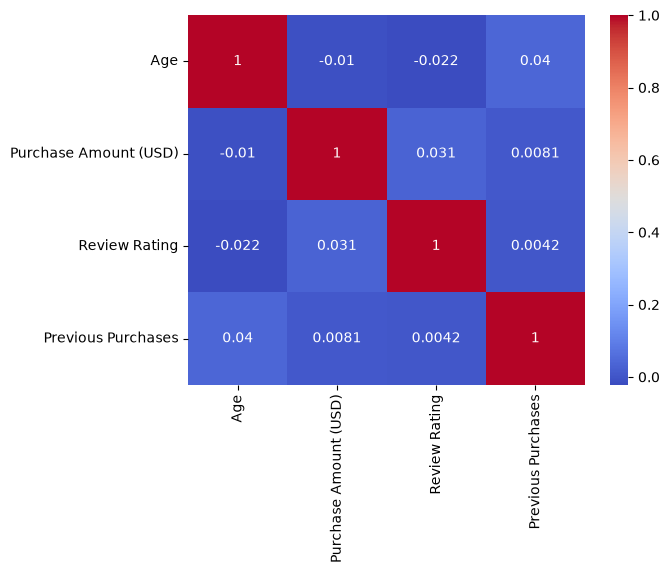

In [45]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr_m = df.corr(numeric_only=True)
sns.heatmap(corr_m, annot=True, cmap='coolwarm')
plt.show()

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [46]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
# df = pd.get_dummies(df, columns=[?], dtype=?)
# df.head()
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [48]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# df['Amount_minmax'] = ?
# df['Age_standard'] = ?
# df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()
df['Amount_minmax'] = MinMaxScaler().fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = StandardScaler().fit_transform(df[['Age']])
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [49]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
# df['Amount_bin'] = ?
# df['Amount_bin'].value_counts()
df['Amount_bin'] = pd.cut(df['Purchase Amount (USD)'], bins=[0, 50, 100, float('inf')], labels=['Low', 'Medium', 'High'])
df['Amount_bin'].value_counts()

Amount_bin
Medium    2386
Low       1514
High         0
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
-  Clothing là danh mục phổ biến nhất ở cả nam và nữ, tiếp theo là Accessories. Footwear và Outerwear ít phổ biến hơn.
- Khách hàng nam chi khoảng 157.890 USD, trong khi khách hàng nữ chi khoảng 75.191 USD.
- Điểm đánh giá trung bình của nam và nữ gần như tương đương (3,73 và 3,70), cho thấy mức độ hài lòng không có sự khác biệt đáng kể.
- Mã khuyến mãi được sử dụng trong 1.677 trên tổng số 3.900 giao dịch.
- Đây là những mối liên hệ quan sát được trong dữ liệu, không khẳng định quan hệ nhân quả

# TODO: write insights
- 
- 
- 
- 

Caveat: correlation is not causation.